# TASK #1: PROJECT OVERVIEW 


In [ ]:
!pip install tensorflow

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns
import pickle
import random
print(tf.__version__)

2.21.0


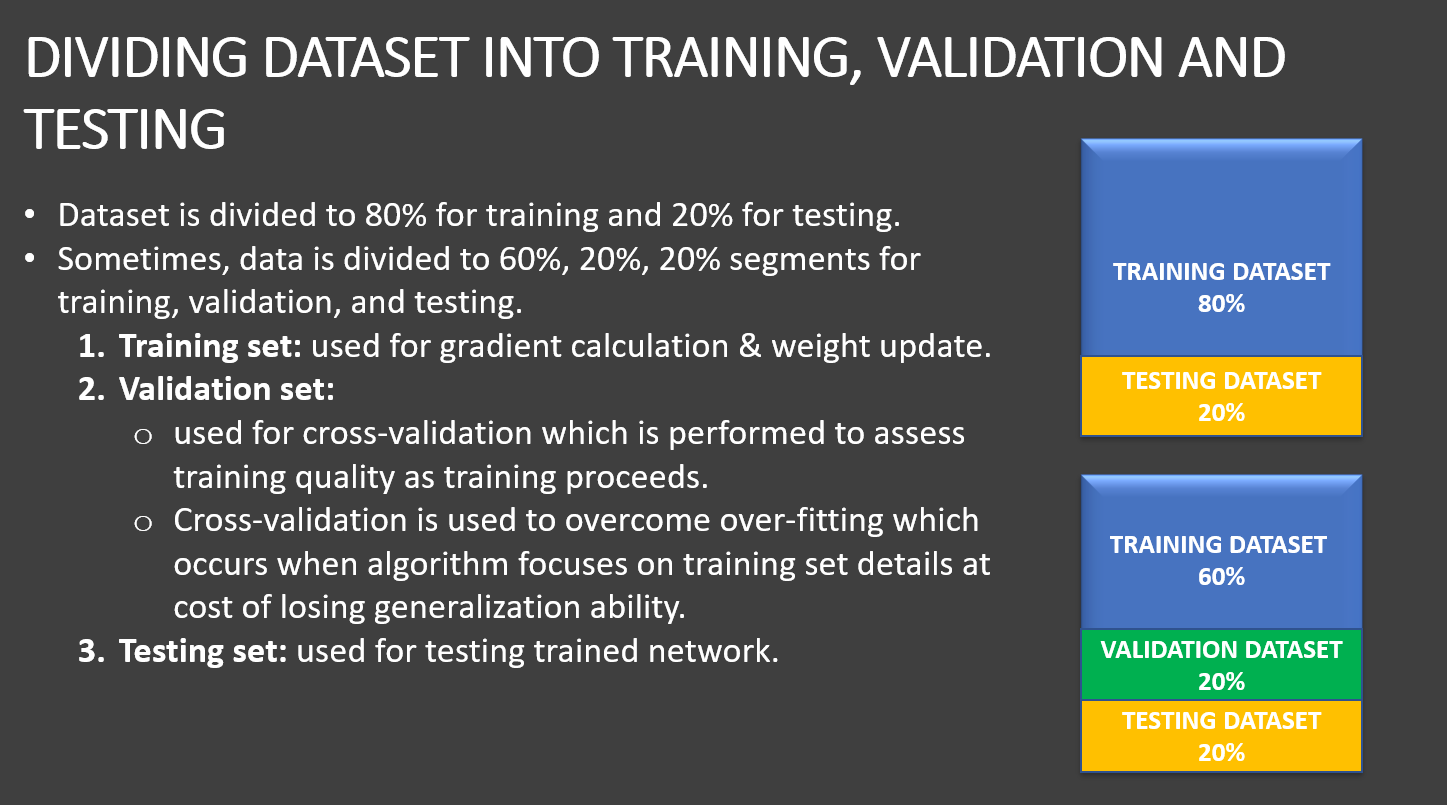

In [4]:
with open("./Problem 1/train.p", mode='rb') as training_data:
    train = pickle.load(training_data)

with open("./Problem 1/valid.p", mode='rb') as validation_data:
    valid = pickle.load(validation_data)

with open("./Problem 1/test.p", mode='rb') as testing_data:
    test = pickle.load(testing_data)

C:\Users\Leo Smith\AppData\Local\Temp\ipykernel_46308\1249630484.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  train = pickle.load(training_data)
C:\Users\Leo Smith\AppData\Local\Temp\ipykernel_46308\1249630484.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  valid = pickle.load(validation_data)
C:\Users\Leo Smith\AppData\Local\Temp\ipykernel_46308\1249630484.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  test = pickle.load(testing_data)


In [5]:
X_train, y_train = train['features'], train['labels']
X_validation, y_validation = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

In [14]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (34799, 32, 32, 3) (34799,)
Validation set: (4410, 32, 32, 3) (4410,)
Test set: (12630, 32, 32, 3) (12630,)


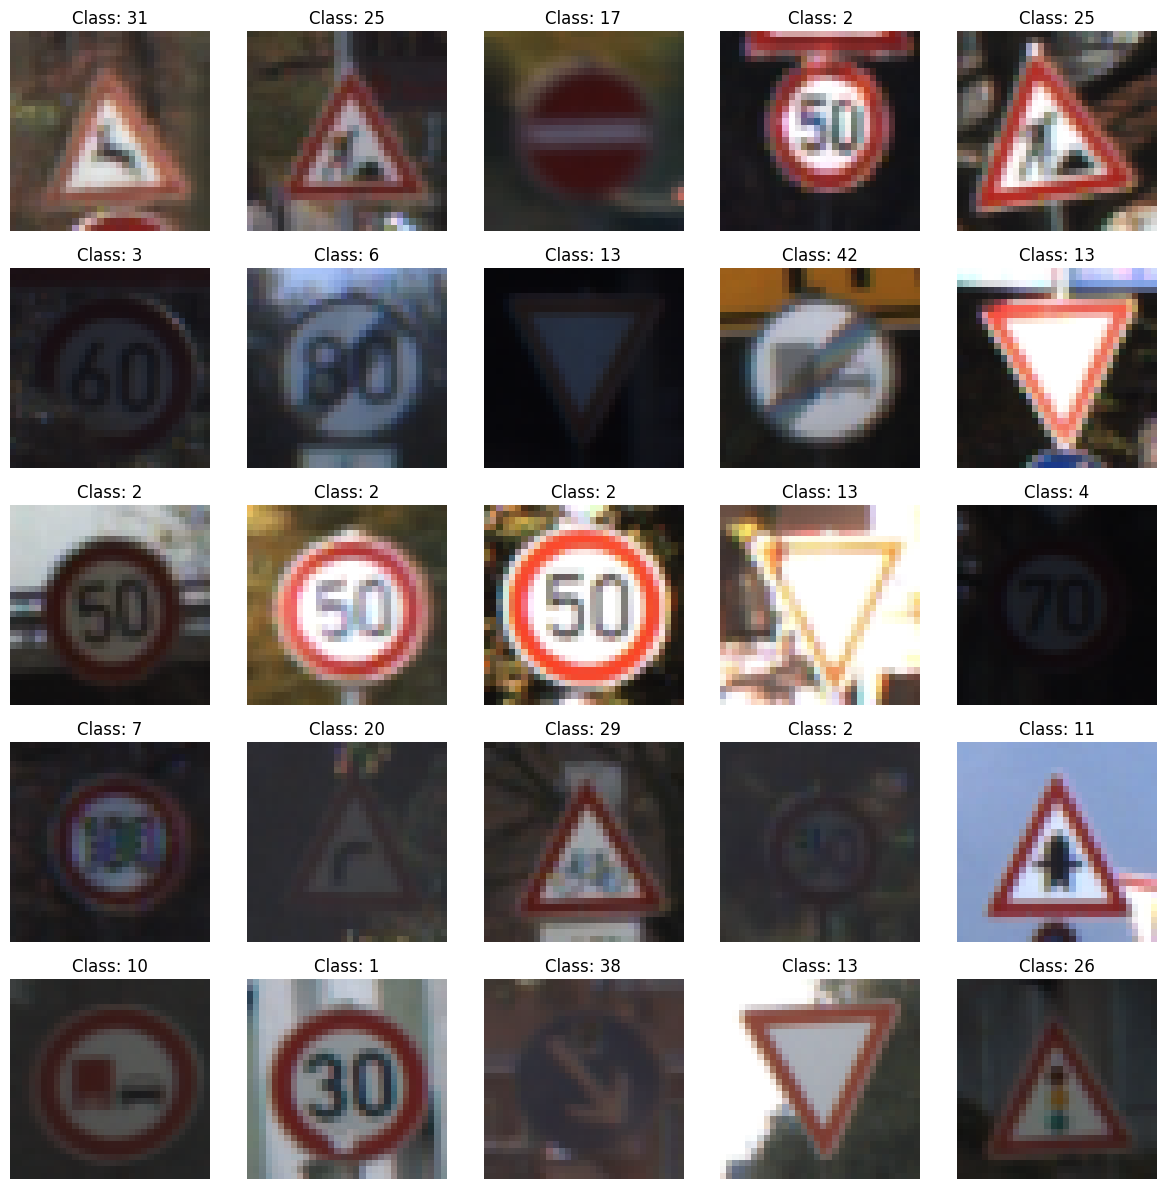

In [15]:
import matplotlib.pyplot as plt
import numpy as np

classes_to_show = 25
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.ravel()

for i in range(classes_to_show):
    index = np.random.randint(0, len(X_train))
    axes[i].imshow(X_train[index])
    axes[i].set_title(f"Class: {y_train[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [16]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_validation, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Number of classes in training set:", len(unique_train))
print("Number of classes in validation set:", len(unique_val))
print("Number of classes in test set:", len(unique_test))

Number of classes in training set: 43
Number of classes in validation set: 43
Number of classes in test set: 43


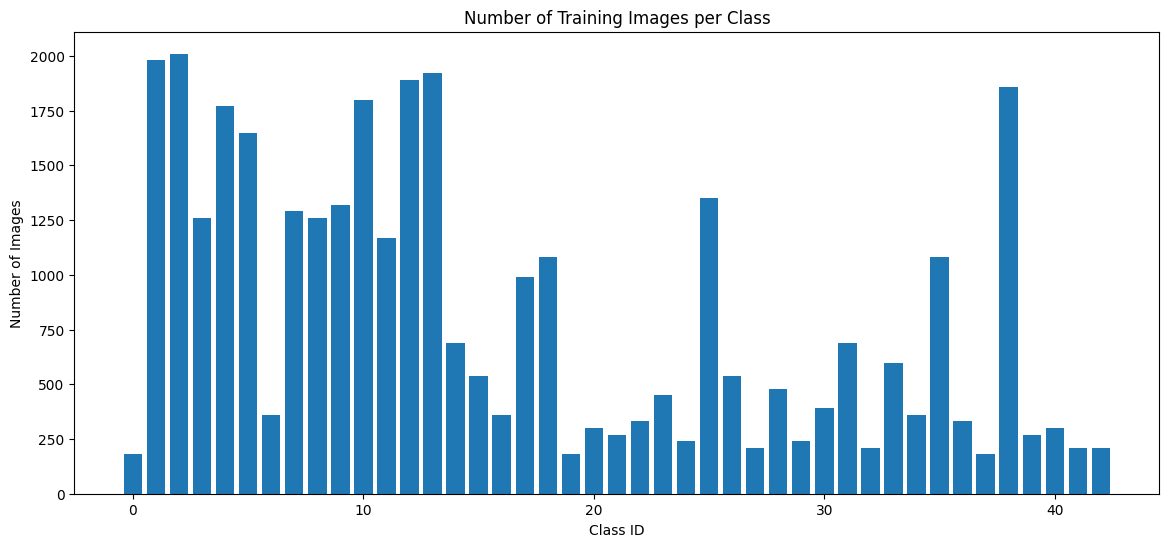

In [17]:
plt.figure(figsize=(14,6))
plt.bar(unique_train, counts_train)
plt.title("Number of Training Images per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.show()

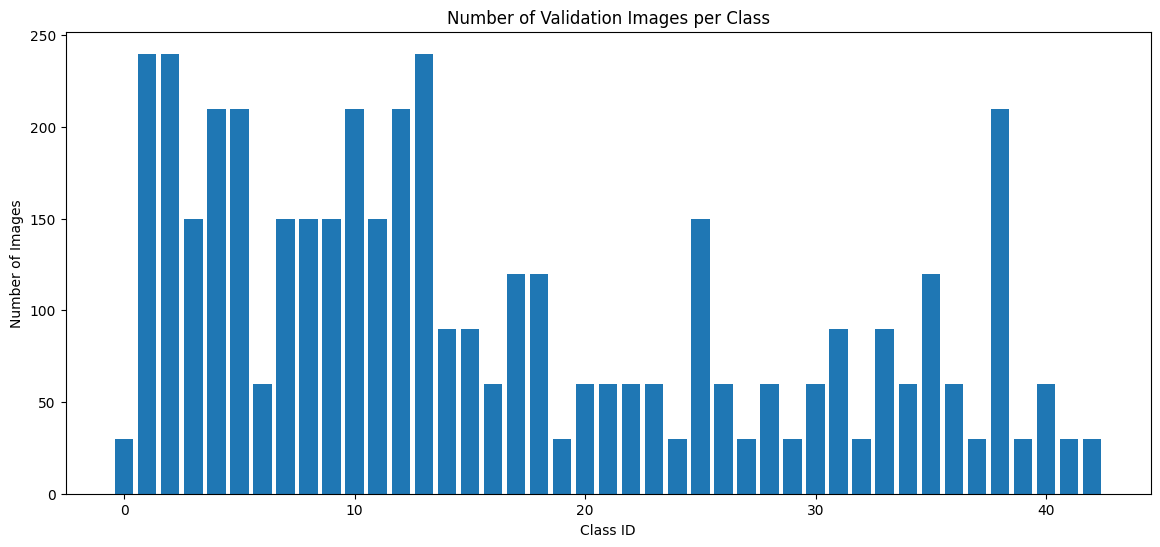

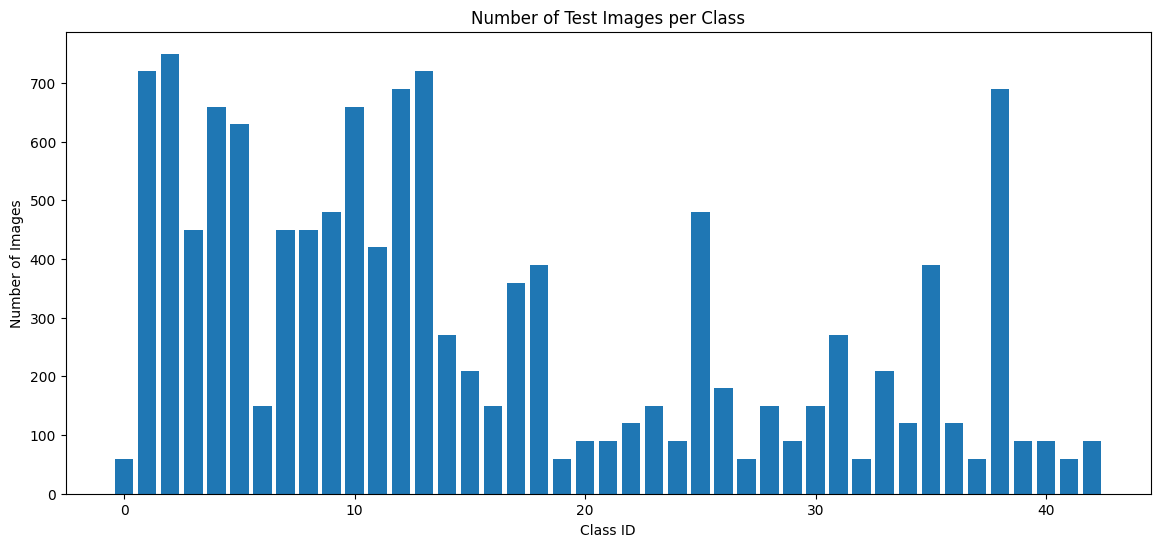

In [18]:
plt.figure(figsize=(14,6))
plt.bar(unique_val, counts_val)
plt.title("Number of Validation Images per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.show()

plt.figure(figsize=(14,6))
plt.bar(unique_test, counts_test)
plt.title("Number of Test Images per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.show()

In [19]:
class_count_df = pd.DataFrame({
    'Class ID': unique_train,
    'Train Count': counts_train,
    'Validation Count': counts_val,
    'Test Count': counts_test
})

class_count_df.head(10)

,Class ID,Train Count,Validation Count,Test Count
0,0,180,30,60
1,1,1980,240,720
2,2,2010,240,750
3,3,1260,150,450
4,4,1770,210,660
5,5,1650,210,630
6,6,360,60,150
7,7,1290,150,450
8,8,1260,150,450
9,9,1320,150,480


In [20]:
class_count_df

,Class ID,Train Count,Validation Count,Test Count
0,0,180,30,60
1,1,1980,240,720
2,2,2010,240,750
3,3,1260,150,450
4,4,1770,210,660
5,5,1650,210,630
6,6,360,60,150
7,7,1290,150,450
8,8,1260,150,450
9,9,1320,150,480


In [6]:
X_train.shape

(34799, 32, 32, 3)

In [7]:
y_train.shape

(34799,)

In [8]:
y_train

array([41, 41, 41, ..., 25, 25, 25], shape=(34799,), dtype=uint8)

# TASK #2: PERFROM IMAGES VISUALIZATION

np.uint8(8)

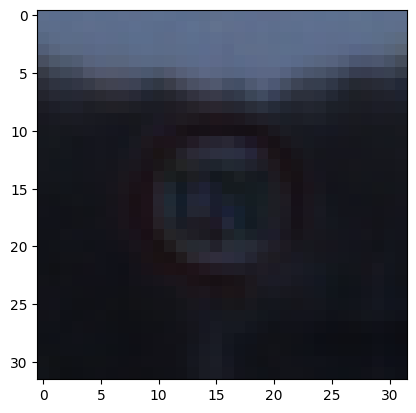

In [21]:
i = np.random.randint(1, len(X_train))
plt.imshow(X_train[i])
y_train[i]

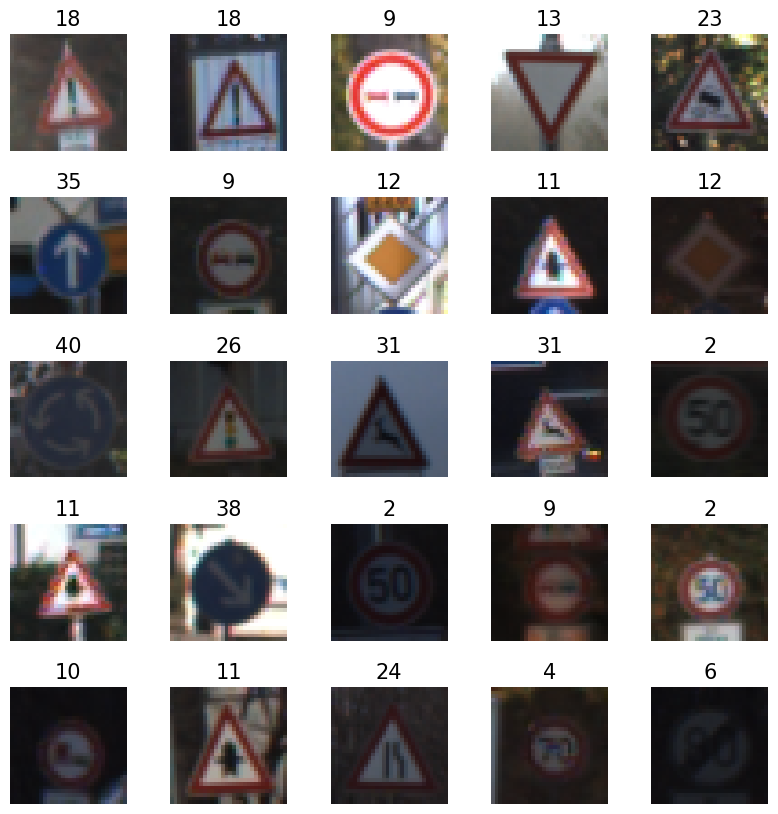

In [22]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid 
W_grid = 5
L_grid = 5

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() # flaten the 15 x 15 matrix into 225 array

n_training = len(X_train) # get the length of the training dataset

# Select a random number from 0 to n_training
for i in np.arange(0, W_grid * L_grid): # create evenly spaces variables 

    # Select a random number
    index = np.random.randint(0, n_training)
    # read and display an image with the selected index    
    axes[i].imshow( X_train[index])
    axes[i].set_title(y_train[index], fontsize = 15)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

        

# TASK #3: CONVERT IMAGES TO GRAYSCALE AND PERFORM NORMALIZATION

In [12]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 7.4 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.1 MB 8.4 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.0 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.1/36.6 MB 10.7 MB/s eta 0:00:04
   ---- ----------------------------------- 3.9/36.6 MB 9.8 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/36.6 MB 10.4 MB/s eta 0:00:03
   ---------- ----------------------------- 9.2/36.6 MB 11.0 MB/s eta 0:00:03
   ------------ --------------------------- 11.3/36.6 MB 10.7 MB/s eta 0:00:03
   -------------- ------------------------- 13.6/36.6 MB 10.8 MB/s eta 0:00:03
   ----------------- ---------------------- 16.0/36.6 MB 10.9 MB/s eta 0:00:02
   --------

In [23]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train)

In [24]:
X_train_gray = np.sum(X_train/3, axis = 3, keepdims = True)
X_test_gray = np.sum(X_test/3, axis = 3, keepdims = True)
X_validation_gray = np.sum(X_validation/3, axis = 3, keepdims = True)

In [25]:
X_train_gray.shape


(34799, 32, 32, 1)

In [27]:
X_test_gray.shape


(12630, 32, 32, 1)

In [28]:
X_train_gray_norm = (X_train_gray - 128)/128
X_test_gray_norm = (X_test_gray - 128)/128
X_validation_gray_norm = (X_validation_gray - 128)/128

In [29]:
X_train_gray_norm

array([[[[-0.79166667],
         [-0.78385417],
         [-0.78645833],
         ...,
         [-0.60416667],
         [-0.62239583],
         [-0.55208333]],

        [[-0.80729167],
         [-0.79166667],
         [-0.79166667],
         ...,
         [-0.64583333],
         [-0.64583333],
         [-0.58854167]],

        [[-0.8046875 ],
         [-0.79166667],
         [-0.79427083],
         ...,
         [-0.69270833],
         [-0.6953125 ],
         [-0.6484375 ]],

        ...,

        [[-0.83333333],
         [-0.8203125 ],
         [-0.81510417],
         ...,
         [-0.8203125 ],
         [-0.8203125 ],
         [-0.82552083]],

        [[-0.83072917],
         [-0.80729167],
         [-0.79427083],
         ...,
         [-0.8203125 ],
         [-0.82291667],
         [-0.82552083]],

        [[-0.8359375 ],
         [-0.79166667],
         [-0.7890625 ],
         ...,
         [-0.8203125 ],
         [-0.8203125 ],
         [-0.81510417]]],


       [[[-0.70572917],


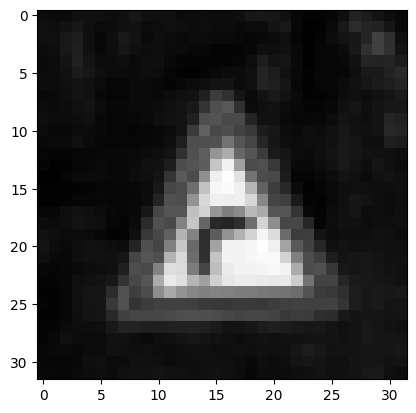

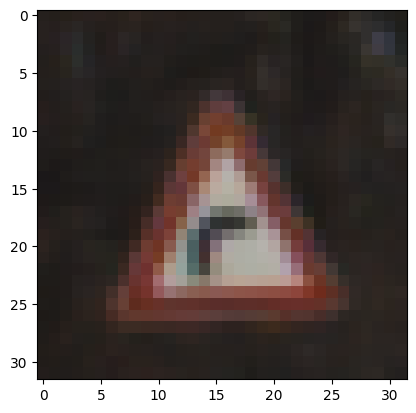

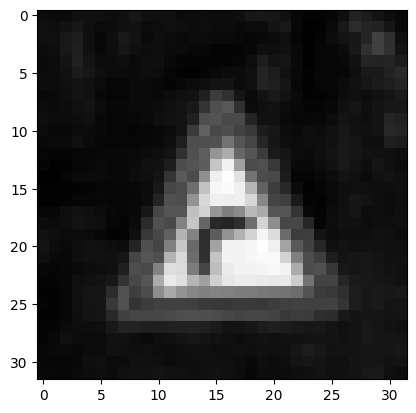

In [30]:
i = random.randint(1, len(X_train_gray))
plt.imshow(X_train_gray[i].squeeze(), cmap = 'gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray_norm[i].squeeze(), cmap = 'gray')

# TASK #4: BUILD DEEP CONVOLUTIONAL NEURAL NETWORK MODEL

In [54]:
from tensorflow.keras import datasets, layers, models

CNN_3 = models.Sequential()

CNN_3.add(layers.Conv2D(6, (5,5), activation='relu', input_shape=(32,32,1)))
CNN_3.add(layers.MaxPooling2D(pool_size=(2,2)))

CNN_3.add(layers.Conv2D(16, (5,5), activation='relu'))
CNN_3.add(layers.MaxPooling2D(pool_size=(2,2)))

CNN_3.add(layers.Flatten())
CNN_3.add(layers.Dense(120, activation='relu'))
CNN_3.add(layers.Dropout(0.5))
CNN_3.add(layers.Dense(84, activation='relu'))
CNN_3.add(layers.Dense(43, activation='softmax'))

CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │         3,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,535 (756.00 KB)

 Trainable params: 64,511 (252.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 129,024 (504.00 KB)

# TASK #5: COMPILE AND TRAIN DEEP CNN MODEL

In [55]:
CNN.compile(optimizer = 'Adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [56]:
history = CNN.fit(X_train_gray_norm,
                 y_train, 
                 batch_size = 500,
                 epochs = 15,
                 verbose = 1,
                 validation_data = (X_validation_gray_norm, y_validation))

Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9059 - val_loss: 0.6433
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9971 - loss: 0.0099 - val_accuracy: 0.9098 - val_loss: 0.5985
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9979 - loss: 0.0072 - val_accuracy: 0.8998 - val_loss: 0.6204
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9984 - loss: 0.0063 - val_accuracy: 0.9066 - val_loss: 0.6857
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9227 - val_loss: 0.6434
Epoch 6/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 0.9236 - val_loss: 0.5338
Epoch 7/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9159 - val_loss: 0.5997
Epoch 8/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9247 - v

# TASK #6: ASSESS TRAINED CNN MODEL PERFORMANCE 

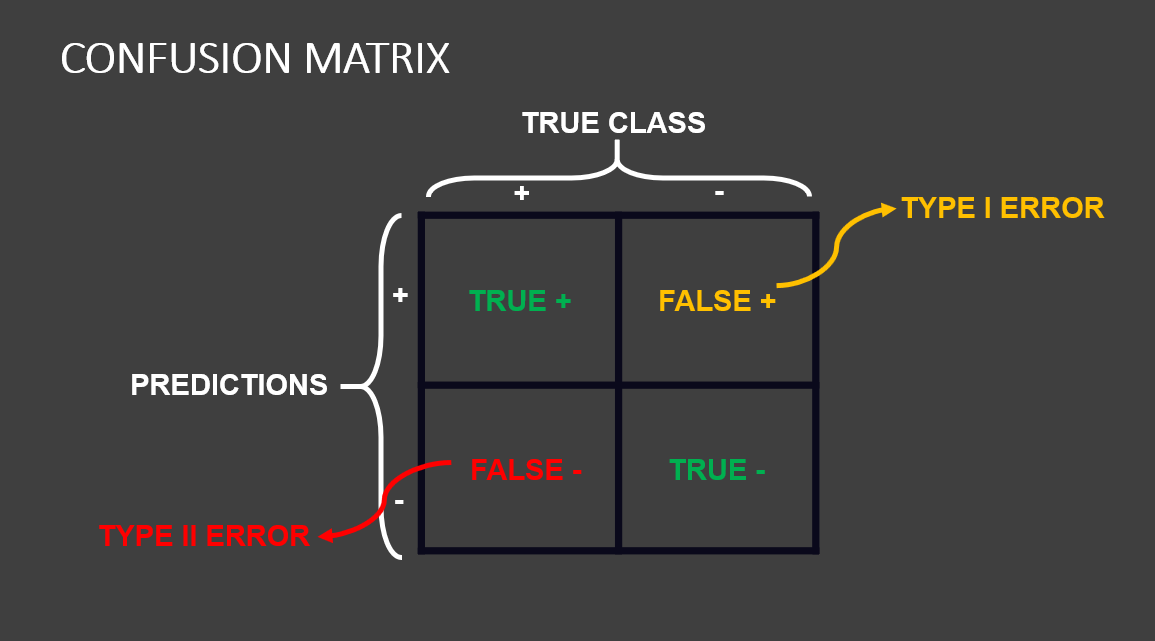

In [57]:
score = CNN.evaluate(X_test_gray_norm, y_test)
print('Test Accuracy: {}'.format(score[1]))

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9054 - loss: 1.1127
Test Accuracy: 0.9053840041160583


In [58]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [59]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

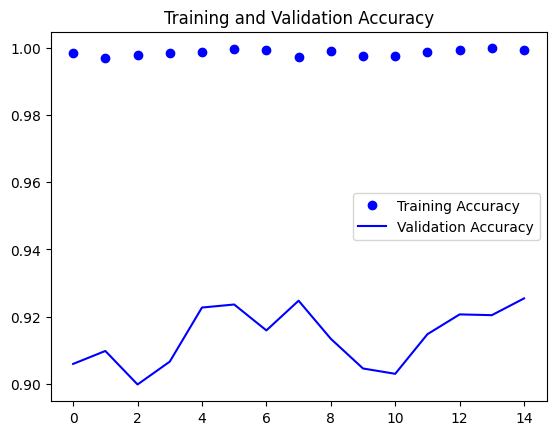

In [60]:
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

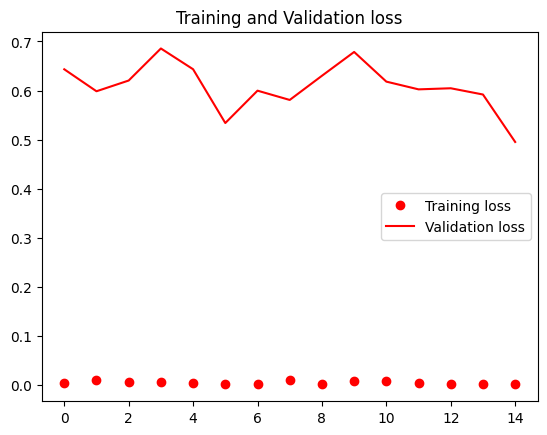

In [61]:
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

In [71]:
model_C = models.Sequential([
    layers.Conv2D(16,(3,3),activation='relu',input_shape=(32,32,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(43,activation='softmax')
])

model_C.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_C = model_C.fit(
    X_train_gray_norm,y_train,
    epochs=15,
    batch_size=500,
    validation_data=(X_validation_gray_norm,y_validation),
    verbose=1
)

score_C = model_C.evaluate(X_test_gray_norm,y_test)

print("Model C Test Accuracy:",score_C[1])

c:\Users\Leo Smith\Downloads\New folder (2)\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.2365 - loss: 2.9497 - val_accuracy: 0.4272 - val_loss: 2.2183
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5850 - loss: 1.4937 - val_accuracy: 0.7213 - val_loss: 1.0814
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7698 - loss: 0.8080 - val_accuracy: 0.8206 - val_loss: 0.6823
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8523 - loss: 0.5300 - val_accuracy: 0.8585 - val_loss: 0.5266
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8944 - loss: 0.3817 - val_accuracy: 0.8805 - val_loss: 0.4271
Epoch 6/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9193 - loss: 0.2974 - val_accuracy: 0.9050 - val_loss: 0.3602
Epoch 7/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9339 - loss: 0.2416 - val_accuracy: 0.9143 - val_loss: 0.3246
Epoch 8/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9443 - loss: 0.2086 - val_accuracy: 0.9050 - v

In [72]:
def plot_history(history, title):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

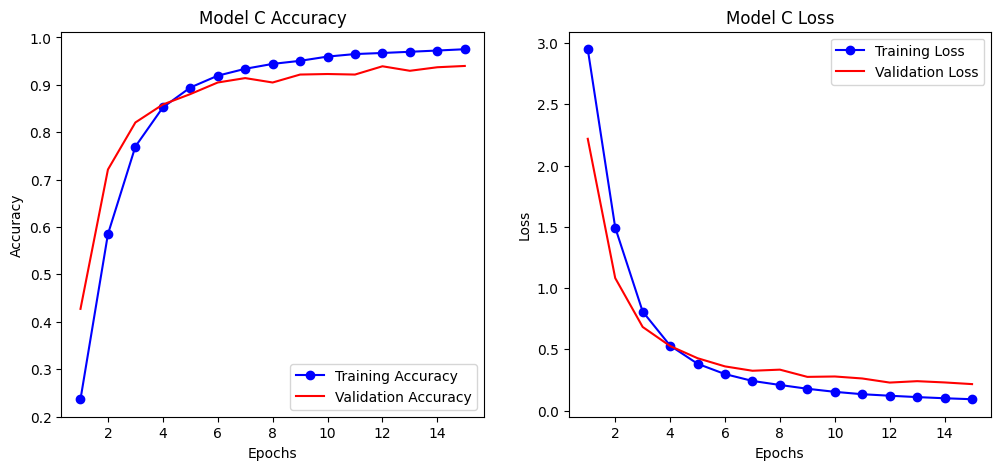

In [73]:
plot_history(history_C,"Model C")

In [ ]:
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

In [30]:
# predicted_classes = CNN.predict_classes(X_test_gray_norm)

y_prob = CNN.predict(X_test_gray_norm)          # shape: (N, 43)
predicted_classes = np.argmax(y_prob, axis=1)   # shape: (N,)
y_true = y_test

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


<Axes: >

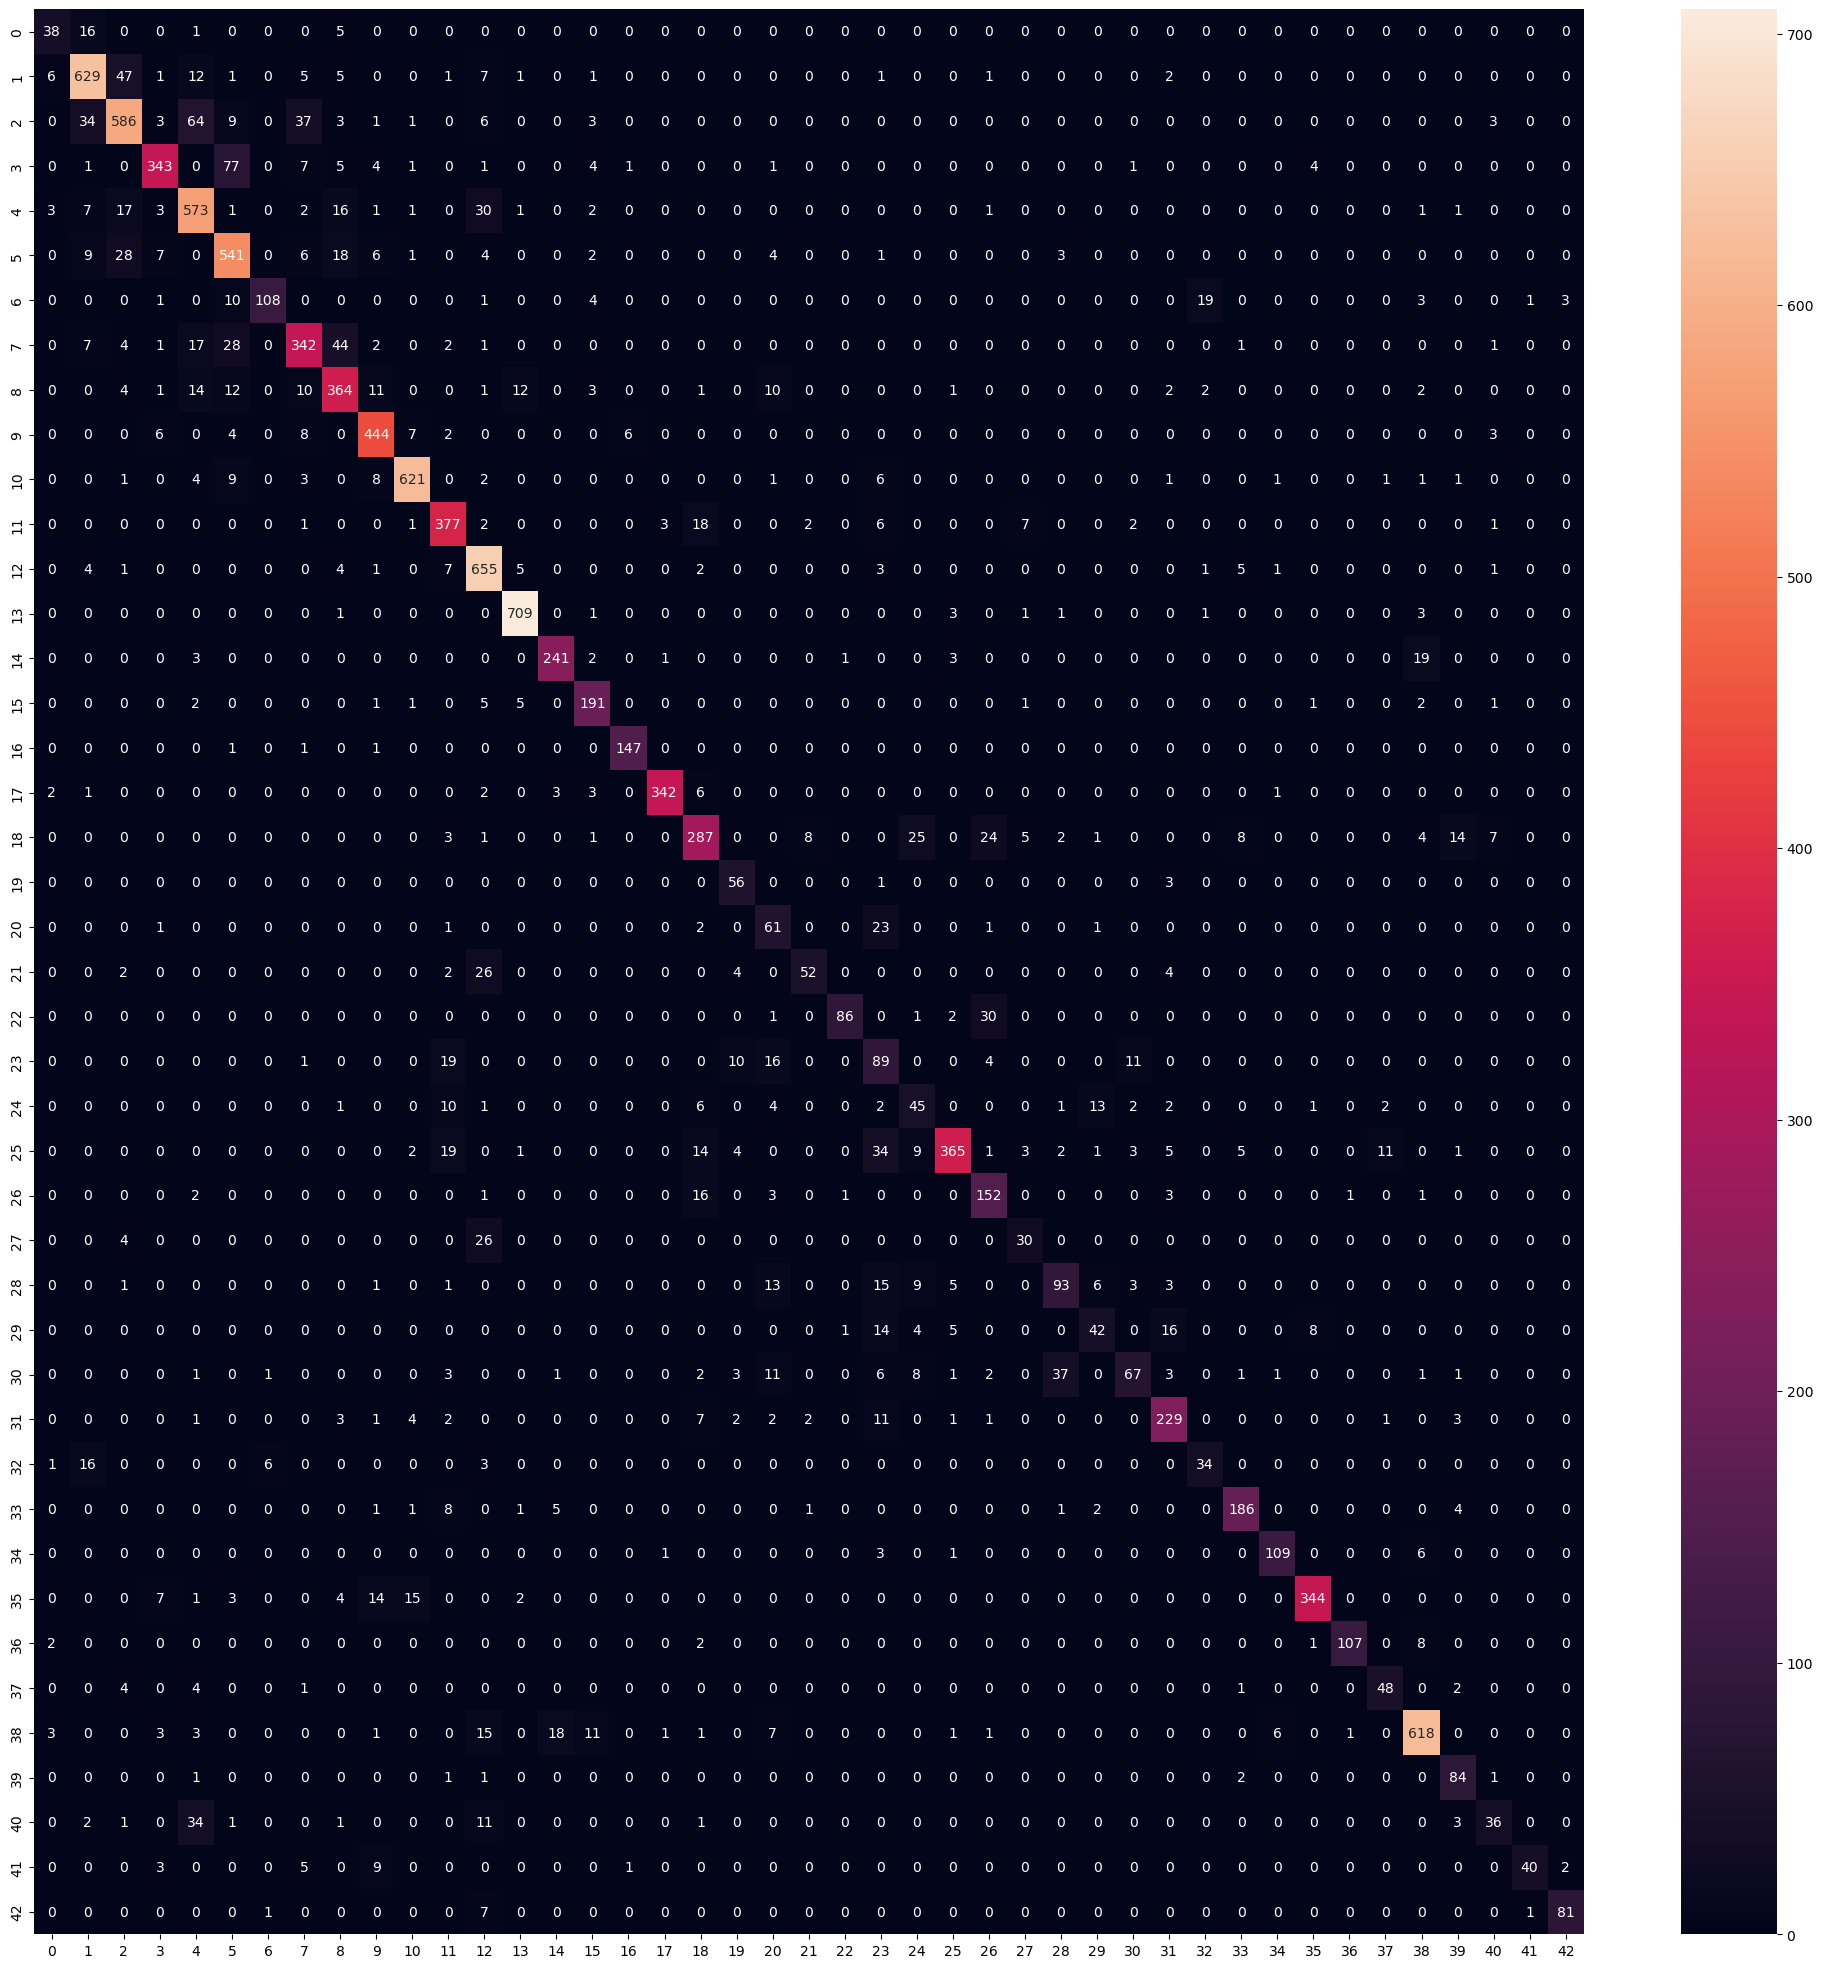

In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize = (25, 25))
sns.heatmap(cm, fmt="d", annot = True);

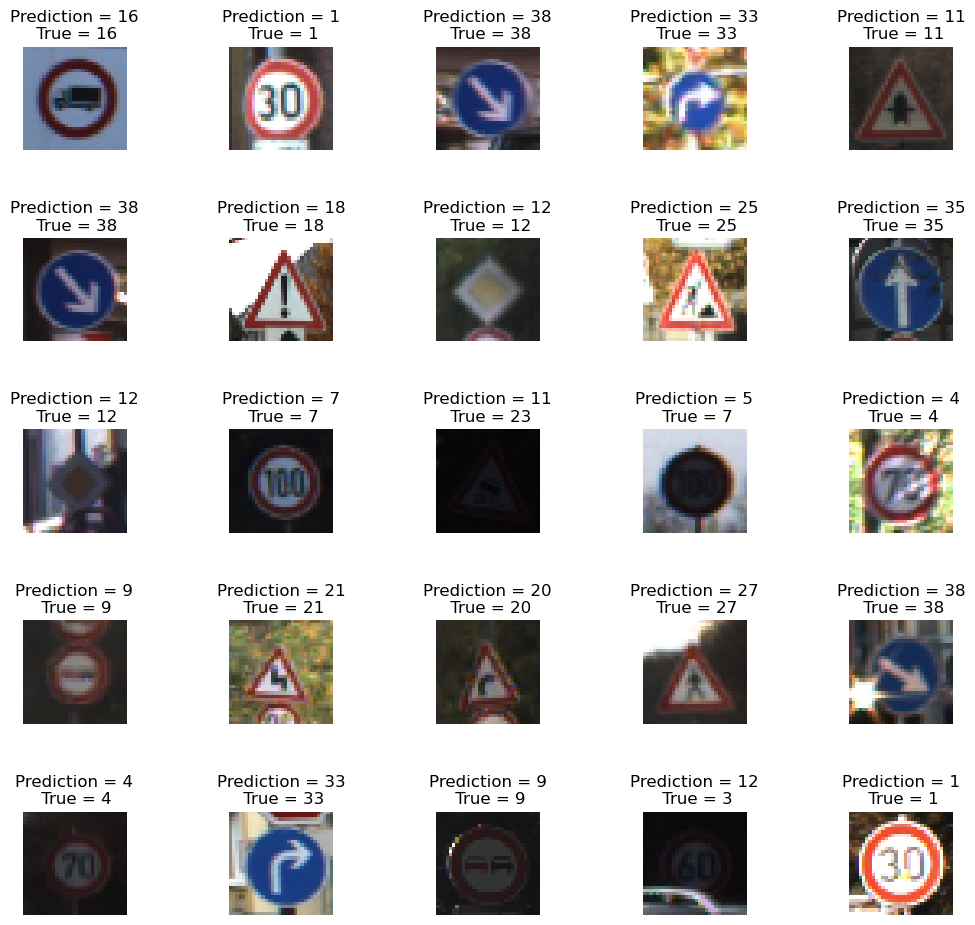

In [32]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Prediction = {}\n True = {}'.format(predicted_classes[i], y_true[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1)    

# GREAT JOB!